## Regular lat-lon grid — plotting methods

The regular lat-lon grid (`regular_ll`) is the most familiar grid type in
meteorology: points are evenly spaced in both latitude and longitude, forming
a uniform rectangular mesh.  ERA5 reanalysis data is distributed on a
0.25° × 0.25° regular lat-lon grid.

Because the grid is regular, all three plotting methods work natively without
any interpolation step:

| Method | How it works | Best for |
|---|---|---|
| `grid_cells` | Draws each grid point as a rectangular cell | Seeing exact cell geometry |
| `point_cloud` | Plots a coloured marker at each grid point | Quick inspection |
| `contourf` | Draws filled contours directly on the grid | Smooth, publication-quality maps |

This notebook uses an ERA5 0.25° 2-metre temperature field.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature = data[0]

era5-2t-msl-1985122512.grib:   0%|          | 0.00/3.96M [00:00<?, ?B/s]

### Shared style

A single `Style` object keeps the colour scale consistent across all panels.

In [2]:
style = ekp.styles.Style(levels=range(-20, 31, 2), colors="Spectral_r", units="celsius")

### All methods side-by-side

We zoom to Europe where the 0.25° cell size is large enough to be visible
in `grid_cells` and `point_cloud`.

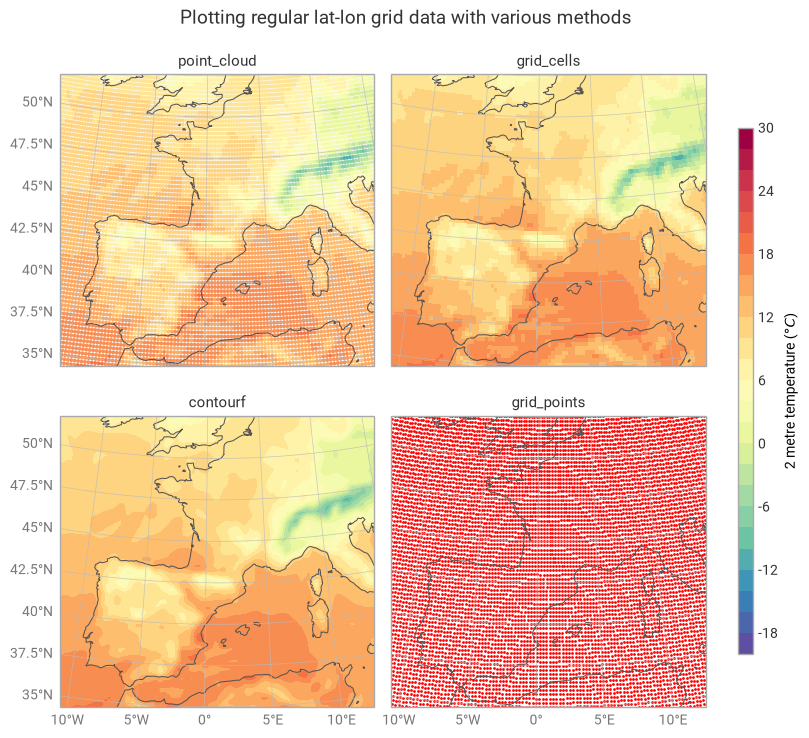

In [3]:
figure = ekp.Figure(rows=2, columns=2, domain=["France", "Spain"])

for method in ["point_cloud", "grid_cells", "contourf", "grid_points"]:
    subplot = figure.add_map()
    getattr(subplot, method)(data, style=style)
    subplot.title(method)

figure.coastlines()
figure.gridlines()

figure.title("Plotting regular lat-lon grid data with various methods")

figure.legend(location="right")

figure.show()

### What to notice

- **`grid_cells`** shows perfectly uniform rectangular cells — the hallmark of
  the regular lat-lon grid.  Unlike HEALPix or reduced Gaussian grids, every
  cell has the same angular width, though their physical area shrinks towards
  the poles.
- **`point_cloud`** at 0.25° resolution is dense enough that the dots form a
  nearly continuous field.  The uniform spacing is clearly visible compared
  to the irregular spacing of the reduced Gaussian grid.
- **`contourf`** is typically the best choice for regular lat-lon data in
  final figures: it requires no interpolation and produces clean, smooth
  contours directly from the grid values.